# Construcción del IC — Seguro Indexado Caldas
**Pipeline:** Parquet → PCA + WI → Backtest → PA2 (VAL) → Selección → Test final → STL → Export

---
## Tabla de contenidos
1. Configuración y carga
2. PA1 — Construcción del IC (2a PCA, 2b WI, 2c Backtest, 2d Diagnóstico)
3. PA2 — Dependencia IC ↔ NDVI_anom sobre VAL (3a Estratos, 3b QR, 3c OLS, 3d Selección + Test)
4. STL — Solo sobre IC definitivo
5. Exportación


## 1. Configuración y carga de datos

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle, joblib, os, warnings
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.seasonal import STL
from statsmodels.regression.quantile_regression import QuantReg
import statsmodels.api as sm
from scipy import stats

warnings.filterwarnings('ignore')
np.random.seed(42)   # semilla fija — reproducibilidad R3

# ── Rutas ──────────────────────────────────────────────────────────
INPUT_DIR  = '../output'    # parquets generados por Procesamiento_v3
OUTPUT_DIR = '../output_ic'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Cargar splits ──────────────────────────────────────────────────
df_train = pd.read_parquet(f'{INPUT_DIR}/df_train.parquet')
df_val   = pd.read_parquet(f'{INPUT_DIR}/df_val.parquet')
df_test  = pd.read_parquet(f'{INPUT_DIR}/df_test.parquet')

# Variables Z que entran al IC (11 variables)
COLS_Z = [
    'Z_tmax', 'Z_tmin', 'Z_skin_temp', 'Z_ppt', 'Z_srad',
    'Z_pet', 'Z_soil_water', 'Z_vap', 'Z_vpd', 'Z_ws', 'Z_BAL'
]

print('Splits cargados:')
for nombre, df in [('TRAIN', df_train), ('VAL', df_val), ('TEST', df_test)]:
    n_ndvi = df['NDVI_anom'].notna().sum()
    print(f'  {nombre}: {len(df):,} filas | '
          f'{df["fecha"].min().date()} → {df["fecha"].max().date()} | '
          f'NDVI válido: {n_ndvi:,} ({n_ndvi/len(df)*100:.1f}%)')

print(f'\nVariables Z disponibles: {len(COLS_Z)}')
print(f'NaN en variables Z (train): {df_train[COLS_Z].isna().sum().sum()}')

Splits cargados:
  TRAIN: 17,934 filas | 2003-01-01 → 2018-12-28 | NDVI válido: 8,829 (49.2%)
  VAL: 3,332 filas | 2019-01-13 → 2021-12-20 | NDVI válido: 1,423 (42.7%)
  TEST: 4,802 filas | 2022-01-05 → 2026-04-06 | NDVI válido: 2,097 (43.7%)

Variables Z disponibles: 11
NaN en variables Z (train): 0


### 1.b Evaluación de techo de correlación de las variables y el NDVI

In [2]:
# =====================================================================
# 1b. Techo de correlación clima ↔ NDVI (diagnóstico previo)
#
# Antes de construir cualquier IC, medimos el LÍMITE TEÓRICO de la
# dependencia clima → NDVI con los datos disponibles. Si una regresión
# lineal múltiple usando TODAS las variables Z no explica más que ~10%
# de la varianza del NDVI_anom, ningún IC (PCA, WI, alternativas) va
# a poder superar ese techo de manera meaningful.
#
# La métrica clave es R² del OLS sobre TRAIN. La correlación equivalente
# (sqrt de R²) es el upper bound de cualquier IC que sea combinación
# lineal de estas variables.
#
# Interpretación del resultado:
#   R² ≥ 0.20  → buena base. Cualquier IC bien construido va a tener
#                señal suficiente para HE positivo.
#   R² 0.10-0.20 → margen estrecho. HE positivo posible pero difícil
#                  de llevar a 55%. Considerar pricing trimestral o
#                  triggers compuestos.
#   R² < 0.10  → techo estructural. Con datos a 11km / 16 días en esta
#                zona, un IC contra NDVI no puede alcanzar HE de mercado.
#                Reformular pregunta o pivotar a entregable diagnóstico.
# =====================================================================

import statsmodels.api as sm

# OLS multivariado: NDVI_anom ~ todas las Z_var
sub_ols = df_train[COLS_Z + ['NDVI_anom']].dropna()
print(f'Observaciones para el OLS: {len(sub_ols):,} '
      f'({len(sub_ols)/len(df_train)*100:.1f}% de train)')

X = sm.add_constant(sub_ols[COLS_Z])
y = sub_ols['NDVI_anom']
modelo_techo = sm.OLS(y, X).fit()

r2     = modelo_techo.rsquared
r2_adj = modelo_techo.rsquared_adj
corr_max = np.sqrt(max(r2, 0))

print(f'\n=== TECHO DE CORRELACIÓN — TRAIN ===')
print(f'  R²              : {r2:.4f}')
print(f'  R² ajustado     : {r2_adj:.4f}')
print(f'  Correlación máx : {corr_max:.4f}  (= sqrt R²)')
print(f'  N observaciones : {len(sub_ols):,}')

# Coeficientes — para ver cuáles variables contribuyen al techo
coefs = pd.DataFrame({
    'coef'   : modelo_techo.params.drop('const'),
    'p_value': modelo_techo.pvalues.drop('const'),
}).sort_values('coef', key=abs, ascending=False)
print(f'\nVariables ordenadas por |coef| (sin constante):')
print(coefs.round(4).to_string())

# Diagnóstico
print(f'\n=== DIAGNÓSTICO ===')
if r2 >= 0.20:
    print(f'  ✅ R² = {r2:.3f} ≥ 0.20  Base sólida para construir IC.')
    print(f'     HE positivo factible con un IC bien calibrado.')
elif r2 >= 0.10:
    print(f'  ~  R² = {r2:.3f} en [0.10, 0.20]  Margen estrecho.')
    print(f'     HE positivo posible. HE >= 55% probablemente requiere')
    print(f'     pricing trimestral o triggers compuestos (no payouts')
    print(f'     a nivel de período de 16 días).')
else:
    print(f'  ❌ R² = {r2:.3f} < 0.10  Techo estructural.')
    print(f'     Causa: lag temporal cultivo, mismatch espacial ERA5↔MODIS,')
    print(f'     o buffer del cultivo bajo sombra. NO se resuelve cambiando')
    print(f'     proxy (NDVI/EVI/SAR) ni QA mask. Reformular el producto')
    print(f'     o pivotar entregable a diagnóstico crítico.')

print(f'\nNOTA: este R² es el TECHO. Cualquier IC que construyamos a')
print(f'continuación tendrá correlación con NDVI_anom <= {corr_max:.3f}.')

Observaciones para el OLS: 8,829 (49.2% de train)

=== TECHO DE CORRELACIÓN — TRAIN ===
  R²              : 0.3938
  R² ajustado     : 0.3931
  Correlación máx : 0.6276  (= sqrt R²)
  N observaciones : 8,829

Variables ordenadas por |coef| (sin constante):
                 coef  p_value
Z_BAL         13.1024   0.0000
Z_ppt        -12.4953   0.0000
Z_pet          0.4744   0.0000
Z_vap         -0.4531   0.0000
Z_vpd          0.3583   0.0000
Z_soil_water   0.1845   0.0000
Z_srad         0.1655   0.0000
Z_ws          -0.1464   0.0000
Z_tmin        -0.0811   0.0005
Z_skin_temp    0.0118   0.6699
Z_tmax        -0.0087   0.5741

=== DIAGNÓSTICO ===
  ✅ R² = 0.394 ≥ 0.20  Base sólida para construir IC.
     HE positivo factible con un IC bien calibrado.

NOTA: este R² es el TECHO. Cualquier IC que construyamos a
continuación tendrá correlación con NDVI_anom <= 0.628.


In [3]:
# Variante con rezagos — descarta lag temporal como única causa del techo bajo
print(f'\n=== TECHO CON REZAGOS (mismo OLS pero IC en t-k) ===')
for lag in [0, 1, 2, 3]:
    df_lag = df_train.sort_values(['lat','lon','fecha']).copy()
    for c in COLS_Z:
        df_lag[f'{c}_lag'] = df_lag.groupby(['lat','lon'])[c].shift(lag)
    sub = df_lag[[f'{c}_lag' for c in COLS_Z] + ['NDVI_anom']].dropna()
    X_lag = sm.add_constant(sub[[f'{c}_lag' for c in COLS_Z]])
    r2_lag = sm.OLS(sub['NDVI_anom'], X_lag).fit().rsquared
    print(f'  Lag {lag} ({lag*16:>2}d): R² = {r2_lag:.4f}  '
          f'corr_max = {np.sqrt(max(r2_lag,0)):.4f}')


=== TECHO CON REZAGOS (mismo OLS pero IC en t-k) ===
  Lag 0 ( 0d): R² = 0.3938  corr_max = 0.6276
  Lag 1 (16d): R² = 0.3755  corr_max = 0.6128
  Lag 2 (32d): R² = 0.3813  corr_max = 0.6175
  Lag 3 (48d): R² = 0.3695  corr_max = 0.6078


## 2. Pregunta analítica 1 — Construcción del IC

Se implementan **dos alternativas** sobre las 11 variables Z estandarizadas por DOY:
- **IC_PCA**: primer componente principal
- **IC_WI**: weighted index con pesos = correlación Spearman con NDVI_anom en train

La selección definitiva se realiza al final de la Pregunta Analítica 2.

Filas para PCA (train, sin NaN): 17,934 de 17,934 (100.0%)

Varianza explicada por componente:
  PC1: 44.8%
  PC2: 25.8%
  PC3: 9.9%
  PC4: 7.8%
  PC5: 5.2%
  PC1 acumula 44.8% — ✅ >= 40%

Loadings PC1 (pesos PCA):
Z_BAL          -0.383
Z_ppt          -0.378
Z_soil_water   -0.347
Z_vap          -0.287
Z_tmin          0.017
Z_tmax          0.044
Z_skin_temp     0.050
Z_ws            0.229
Z_srad          0.364
Z_pet           0.391
Z_vpd           0.406



IC_PCA generado:
  TRAIN: media=0.000 | std=2.219 | rango=[-6.93, 7.92]
  VAL: media=0.504 | std=2.552 | rango=[-7.78, 8.87]
  TEST: media=-0.216 | std=2.474 | rango=[-8.99, 8.30]


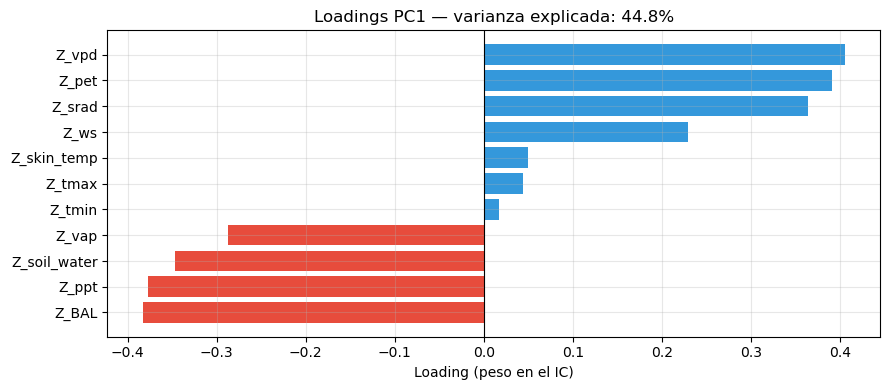

In [4]:
# =====================================================================
# 2a. PCA → IC_PCA
#
# Se ajusta PCA sobre df_train (sin NaN en COLS_Z).
# Se aplica a los tres splits.
# El IC es el primer componente principal, estandarizado a z-score.
# =====================================================================

# Filas completas en train (sin NaN en variables Z)
train_pca = df_train[COLS_Z].dropna()
print(f'Filas para PCA (train, sin NaN): {len(train_pca):,} '
      f'de {len(df_train):,} ({len(train_pca)/len(df_train)*100:.1f}%)')

# Ajustar PCA en train
pca = PCA(n_components=len(COLS_Z))
pca.fit(train_pca)

var_explicada = pca.explained_variance_ratio_
print(f'\nVarianza explicada por componente:')
for i, v in enumerate(var_explicada[:5]):
    print(f'  PC{i+1}: {v*100:.1f}%')
print(f'  PC1 acumula {var_explicada[0]*100:.1f}% — '
      f'{"✅ >= 40%" if var_explicada[0] >= 0.4 else "⚠️ < 40% — revisar"}')

# Pesos (loadings) del primer componente
loadings_pca = pd.Series(pca.components_[0], index=COLS_Z).sort_values()
print(f'\nLoadings PC1 (pesos PCA):')
print(loadings_pca.round(3).to_string())

# Aplicar a los tres splits
def aplicar_pca(df, pca_model, cols_z):
    df = df.copy()
    mask = df[cols_z].notna().all(axis=1)
    ic = np.full(len(df), np.nan)
    if mask.sum() > 0:
        scores = pca_model.transform(df.loc[mask, cols_z])
        ic[mask] = scores[:, 0]
    df['IC_PCA'] = ic
    return df

df_train = aplicar_pca(df_train, pca, COLS_Z)
df_val   = aplicar_pca(df_val,   pca, COLS_Z)
df_test  = aplicar_pca(df_test,  pca, COLS_Z)

print(f'\nIC_PCA generado:')
for nombre, df in [('TRAIN', df_train), ('VAL', df_val), ('TEST', df_test)]:
    ic = df['IC_PCA'].dropna()
    print(f'  {nombre}: media={ic.mean():.3f} | std={ic.std():.3f} | '
          f'rango=[{ic.min():.2f}, {ic.max():.2f}]')

# Visualización de loadings
fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#E74C3C' if v < 0 else '#3498DB' for v in loadings_pca.values]
ax.barh(loadings_pca.index, loadings_pca.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title(f'Loadings PC1 — varianza explicada: {var_explicada[0]*100:.1f}%')
ax.set_xlabel('Loading (peso en el IC)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Filas para WI (train, con NDVI válido): 8,829

Correlaciones Spearman Z_var ↔ NDVI_anom (train):
Z_srad          0.443
Z_pet           0.395
Z_vpd           0.285
Z_ws            0.150
Z_tmax          0.004
Z_soil_water   -0.221
Z_ppt          -0.239
Z_BAL          -0.248
Z_skin_temp    -0.258
Z_tmin         -0.280
Z_vap          -0.538

Pesos WI (normalizados, suma abs = 1.000):
Z_srad          0.145
Z_pet           0.129
Z_vpd           0.093
Z_ws            0.049
Z_tmax          0.001
Z_soil_water   -0.072
Z_ppt          -0.078
Z_BAL          -0.081
Z_skin_temp    -0.084
Z_tmin         -0.092
Z_vap          -0.176

IC_WI generado:
  TRAIN: media=-0.000 | std=0.687 | rango=[-1.66, 2.20]
  VAL: media=0.114 | std=0.765 | rango=[-1.73, 2.18]
  TEST: media=-0.099 | std=0.755 | rango=[-2.01, 2.32]


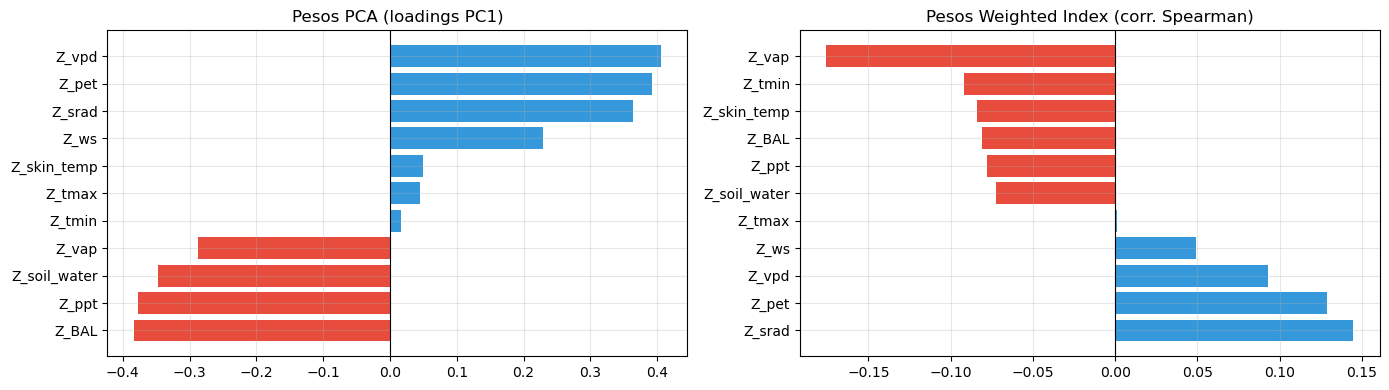

In [5]:
# =====================================================================
# 2b. Weighted Index → IC_WI
#
# Pesos = correlación de Spearman entre cada Z_var y NDVI_anom en TRAIN.
# Solo se usan filas donde NDVI_anom no es NaN para calcular los pesos.
# Se normalizan los pesos para que sumen 1 en valor absoluto.
# Se aplica a los tres splits usando los pesos de TRAIN.
#
# Nota: esto introduce dependencia entre construcción del IC y la
# variable de validación. Los pesos se calculan SOLO en train y no
# se reajustan, para evitar data leakage.
# =====================================================================

# Calcular correlaciones Spearman en train (solo filas con NDVI válido)
train_wi = df_train[COLS_Z + ['NDVI_anom']].dropna()
print(f'Filas para WI (train, con NDVI válido): {len(train_wi):,}')

correlaciones = {}
for col in COLS_Z:
    r, p = stats.spearmanr(train_wi[col], train_wi['NDVI_anom'])
    correlaciones[col] = r

corr_series = pd.Series(correlaciones).sort_values(ascending=False)
print('\nCorrelaciones Spearman Z_var ↔ NDVI_anom (train):')
print(corr_series.round(3).to_string())

# Pesos normalizados (suma de valores absolutos = 1)
pesos_wi = corr_series / corr_series.abs().sum()
print(f'\nPesos WI (normalizados, suma abs = {pesos_wi.abs().sum():.3f}):')
print(pesos_wi.round(3).to_string())

# Aplicar a los tres splits
def aplicar_wi(df, pesos, cols_z):
    df = df.copy()
    mask = df[cols_z].notna().all(axis=1)
    ic = np.full(len(df), np.nan)
    if mask.sum() > 0:
        X = df.loc[mask, cols_z]
        ic[mask] = X.values @ pesos[cols_z].values
    df['IC_WI'] = ic
    return df

df_train = aplicar_wi(df_train, pesos_wi, COLS_Z)
df_val   = aplicar_wi(df_val,   pesos_wi, COLS_Z)
df_test  = aplicar_wi(df_test,  pesos_wi, COLS_Z)

print(f'\nIC_WI generado:')
for nombre, df in [('TRAIN', df_train), ('VAL', df_val), ('TEST', df_test)]:
    ic = df['IC_WI'].dropna()
    print(f'  {nombre}: media={ic.mean():.3f} | std={ic.std():.3f} | '
          f'rango=[{ic.min():.2f}, {ic.max():.2f}]')

# Comparación de pesos PCA vs WI
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (valores, titulo) in zip(axes, [
    (loadings_pca, 'Pesos PCA (loadings PC1)'),
    (pesos_wi,     'Pesos Weighted Index (corr. Spearman)')
]):
    cols = list(valores.index)
    vals = list(valores.values)
    colors = ['#E74C3C' if v < 0 else '#3498DB' for v in vals]
    ax.barh(cols, vals, color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(titulo)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
# =====================================================================
# 2b.2  Corrección de signo del IC_PCA + análisis de rezago
#
# PLAN 1 — Corrección de signo:
#   El primer componente principal tiene signo arbitrario. Si el IC_PCA
#   sale con signo invertido, valores altos del IC corresponden a estrés
#   (bajo NDVI) y el trigger IC < p10 captura las observaciones incorrectas.
#   Se verifica la correlación Spearman IC_PCA ↔ NDVI_anom en train:
#   - Si ρ < 0: el IC está invertido → negarlo
#   - Si ρ > 0: el IC ya está en la dirección correcta
#
# PLAN 2 — Rezago temporal:
#   El NDVI puede responder al estrés climático con 1–3 períodos de retraso
#   (16–48 días). Si la correlación mejora con rezago, se usa el IC rezagado
#   como predictor. Se evalúa sobre AMBOS ICs (PCA y WI).
# =====================================================================

# ── PLAN 1: Verificar y corregir signo ───────────────────────────────

for nombre_ic, col_ic in [('IC_PCA', 'IC_PCA'), ('IC_WI', 'IC_WI')]:
    train_valido = df_train[[col_ic, 'NDVI_anom']].dropna()
    corr, _ = stats.spearmanr(train_valido[col_ic], train_valido['NDVI_anom'])
    print(f"Correlación {nombre_ic} ↔ NDVI_anom (train): ρ = {corr:.3f}")

    if corr < 0:
        print(f"  → ρ < 0: {nombre_ic} está invertido. Negando...")
        for df in [df_train, df_val, df_test]:
            df[col_ic] = -df[col_ic]
        # Verificar corrección
        train_valido2 = df_train[[col_ic, 'NDVI_anom']].dropna()
        corr2, _ = stats.spearmanr(train_valido2[col_ic],
                                    train_valido2['NDVI_anom'])
        print(f"  → Correlación después de corrección: ρ = {corr2:.3f} ✅")
    else:
        print(f"  → ρ > 0: {nombre_ic} ya está en la dirección correcta ✅")
    print()

# ── PLAN 2: Análisis de rezago ────────────────────────────────────────
# Se evalúa lag 0, 1, 2, 3 (0, 16, 32, 48 días) para ambos ICs.
# Los parámetros se calculan pixel a pixel para evitar mezclar
# series temporales de distintas ubicaciones geográficas.

print("\n=== ANÁLISIS DE REZAGO (train) ===")
print("Correlación Spearman IC(t-lag) ↔ NDVI_anom(t)")
print("─" * 50)

train_sorted = df_train.sort_values(['lat', 'lon', 'fecha'])

lag_results = {}
for col_ic in ['IC_PCA', 'IC_WI']:
    lag_results[col_ic] = {}
    pares_por_lag = {lag: [] for lag in range(4)}

    for (lat, lon), grupo in train_sorted.groupby(['lat', 'lon']):
        grupo = grupo.sort_values('fecha').reset_index(drop=True)
        ndvi  = grupo['NDVI_anom']
        for lag in range(4):
            ic_lag = grupo[col_ic].shift(lag)
            validos = ic_lag.notna() & ndvi.notna()
            if validos.sum() >= 10:
                pares_por_lag[lag].append(
                    pd.DataFrame({'ic': ic_lag[validos].values,
                                  'ndvi': ndvi[validos].values})
                )

    print(f"\n  {col_ic}:")
    mejor_lag = 0
    mejor_corr = -999
    for lag in range(4):
        if pares_por_lag[lag]:
            df_pares = pd.concat(pares_por_lag[lag], ignore_index=True)
            r, _ = stats.spearmanr(df_pares['ic'], df_pares['ndvi'])
            lag_results[col_ic][lag] = round(r, 4)
            marker = ''
            if r > mejor_corr:
                mejor_corr = r
                mejor_lag  = lag
            print(f"    Lag {lag} ({lag*16:2d} días): ρ = {r:.4f}")
        else:
            lag_results[col_ic][lag] = None
            print(f"    Lag {lag}: sin datos suficientes")

    mejora = lag_results[col_ic][mejor_lag] - lag_results[col_ic][0]
    print(f"    → Mejor lag: {mejor_lag} ({mejor_lag*16} días), "
          f"ρ = {lag_results[col_ic][mejor_lag]:.4f} "
          f"(mejora vs lag0: {mejora:+.4f})")

    if mejor_lag > 0 and mejora > 0.02:
        print(f"    ⚠️  El rezago mejora la correlación en > 0.02.")
        print(f"       Considerar usar IC rezagado {mejor_lag} período(s) "
              f"como predictor en PA2.")
    else:
        print(f"    ✅  El rezago no mejora significativamente (< 0.02).")
        print(f"       Se usa lag=0 (contemporáneo).")

# ── Decisión sobre rezago ─────────────────────────────────────────────
print("\n=== DECISIÓN SOBRE REZAGO ===")
print("Si algún IC mejora > 0.02 con rezago, aplicar shift antes de PA2.")
print("El shift se aplica por píxel para preservar la estructura espacial.")
print("\nPara aplicar rezago lag=N en PA2, agregar antes de ajustar QR/OLS:")
print("  df['IC_PCA_lag'] = df.groupby(['lat','lon'])['IC_PCA'].shift(N)")
print("  (reemplazar IC_PCA por IC_PCA_lag en las funciones de regresión)")


Correlación IC_PCA ↔ NDVI_anom (train): ρ = 0.346
  → ρ > 0: IC_PCA ya está en la dirección correcta ✅

Correlación IC_WI ↔ NDVI_anom (train): ρ = 0.495
  → ρ > 0: IC_WI ya está en la dirección correcta ✅


=== ANÁLISIS DE REZAGO (train) ===
Correlación Spearman IC(t-lag) ↔ NDVI_anom(t)
──────────────────────────────────────────────────

  IC_PCA:
    Lag 0 ( 0 días): ρ = 0.3465
    Lag 1 (16 días): ρ = 0.3346
    Lag 2 (32 días): ρ = 0.3463
    Lag 3 (48 días): ρ = 0.3382
    → Mejor lag: 0 (0 días), ρ = 0.3465 (mejora vs lag0: +0.0000)
    ✅  El rezago no mejora significativamente (< 0.02).
       Se usa lag=0 (contemporáneo).

  IC_WI:
    Lag 0 ( 0 días): ρ = 0.4952
    Lag 1 (16 días): ρ = 0.4809
    Lag 2 (32 días): ρ = 0.4913
    Lag 3 (48 días): ρ = 0.4880
    → Mejor lag: 0 (0 días), ρ = 0.4952 (mejora vs lag0: +0.0000)
    ✅  El rezago no mejora significativamente (< 0.02).
       Se usa lag=0 (contemporáneo).

=== DECISIÓN SOBRE REZAGO ===
Si algún IC mejora > 0.02 con rezag

In [7]:
# =====================================================================
# 2c. Backtest de estabilidad — expanding window
#
# Se reportan variación RELATIVA (std/mean_abs) y ABSOLUTA (std).
# La variación relativa es engañosa cuando el loading es ~0:
# un loading de 0.002 ± 0.005 tiene variación relativa del 250%
# pero impacto negligible en el IC.
# Criterio real de inestabilidad: rel > 15% AND abs > 0.01.
# =====================================================================

df_all_train = df_train.copy()
anios_train  = sorted(df_all_train['fecha'].dt.year.unique())
ventanas     = [(anios_train[0], y) for y in anios_train[5::3]]

print(f'Expanding window backtest — {len(ventanas)} ventanas:')

loadings_por_ventana_pca = []
pesos_por_ventana_wi     = []

for inicio, fin in ventanas:
    mask   = (df_all_train['fecha'].dt.year >= inicio) & \
             (df_all_train['fecha'].dt.year <= fin)
    subset = df_all_train.loc[mask, COLS_Z].dropna()
    if len(subset) < 30:
        continue

    pca_v = PCA(n_components=1)
    pca_v.fit(subset)
    loadings_v = pd.Series(pca_v.components_[0], index=COLS_Z)
    if np.corrcoef(loadings_v.values,
                   loadings_pca.reindex(COLS_Z).values)[0,1] < 0:
        loadings_v = -loadings_v
    loadings_por_ventana_pca.append((fin, loadings_v))

    subset_wi = df_all_train.loc[mask, COLS_Z + ['NDVI_anom']].dropna()
    if len(subset_wi) > 10:
        corr_v = {c: stats.spearmanr(subset_wi[c],
                  subset_wi['NDVI_anom'])[0] for c in COLS_Z}
        pesos_v = pd.Series(corr_v)
        pesos_v = pesos_v / pesos_v.abs().sum()
        pesos_por_ventana_wi.append((fin, pesos_v))

    print(f'  Ventana {inicio}–{fin}: {len(subset):,} obs. PCA | '
          f'{len(subset_wi):,} obs. WI')

# ── Métricas PCA ──────────────────────────────────────────────────────
if len(loadings_por_ventana_pca) >= 2:
    df_load_pca      = pd.DataFrame(
        {fin: l for fin, l in loadings_por_ventana_pca}).T
    variacion_rel_pca = df_load_pca.std() / df_load_pca.abs().mean()
    variacion_abs_pca = df_load_pca.std()

    print('\nEstabilidad PCA — por variable (relativa | absoluta):')
    for col in variacion_rel_pca.sort_values(ascending=False).index:
        vr = variacion_rel_pca[col]
        va = variacion_abs_pca[col]
        if vr > 0.15 and va > 0.01:
            flag = '⚠️  inestabilidad real'
        elif vr > 0.15:
            flag = '~0  loading negligible (artefacto del indicador)'
        else:
            flag = '✅'
        print(f'  {col:<15}: rel={vr:.3f}  abs={va:.4f}  {flag}')

# ── Métricas WI ───────────────────────────────────────────────────────
if len(pesos_por_ventana_wi) >= 2:
    df_pesos_wi       = pd.DataFrame(
        {fin: p for fin, p in pesos_por_ventana_wi}).T
    variacion_rel_wi  = df_pesos_wi.std() / df_pesos_wi.abs().mean()
    variacion_abs_wi  = df_pesos_wi.std()

    print('\nEstabilidad WI — por variable (relativa | absoluta):')
    for col in variacion_rel_wi.sort_values(ascending=False).index:
        vr = variacion_rel_wi[col]
        va = variacion_abs_wi[col]
        if vr > 0.15 and va > 0.01:
            flag = '⚠️  inestabilidad real'
        elif vr > 0.15:
            flag = '~0  peso negligible'
        else:
            flag = '✅'
        print(f'  {col:<15}: rel={vr:.3f}  abs={va:.4f}  {flag}')


Expanding window backtest — 4 ventanas:
  Ventana 2003–2008: 6,713 obs. PCA | 3,122 obs. WI
  Ventana 2003–2011: 10,094 obs. PCA | 4,583 obs. WI
  Ventana 2003–2014: 13,426 obs. PCA | 6,339 obs. WI
  Ventana 2003–2017: 16,807 obs. PCA | 8,200 obs. WI

Estabilidad PCA — por variable (relativa | absoluta):
  Z_tmin         : rel=1.053  abs=0.0134  ⚠️  inestabilidad real
  Z_tmax         : rel=0.686  abs=0.0148  ⚠️  inestabilidad real
  Z_skin_temp    : rel=0.406  abs=0.0129  ⚠️  inestabilidad real
  Z_ws           : rel=0.082  abs=0.0165  ✅
  Z_vpd          : rel=0.041  abs=0.0154  ✅
  Z_srad         : rel=0.030  abs=0.0115  ✅
  Z_vap          : rel=0.022  abs=0.0063  ✅
  Z_soil_water   : rel=0.022  abs=0.0074  ✅
  Z_ppt          : rel=0.019  abs=0.0075  ✅
  Z_BAL          : rel=0.019  abs=0.0076  ✅
  Z_pet          : rel=0.017  abs=0.0070  ✅

Estabilidad WI — por variable (relativa | absoluta):
  Z_tmax         : rel=1.159  abs=0.0064  ~0  peso negligible
  Z_soil_water   : rel=0.199  a

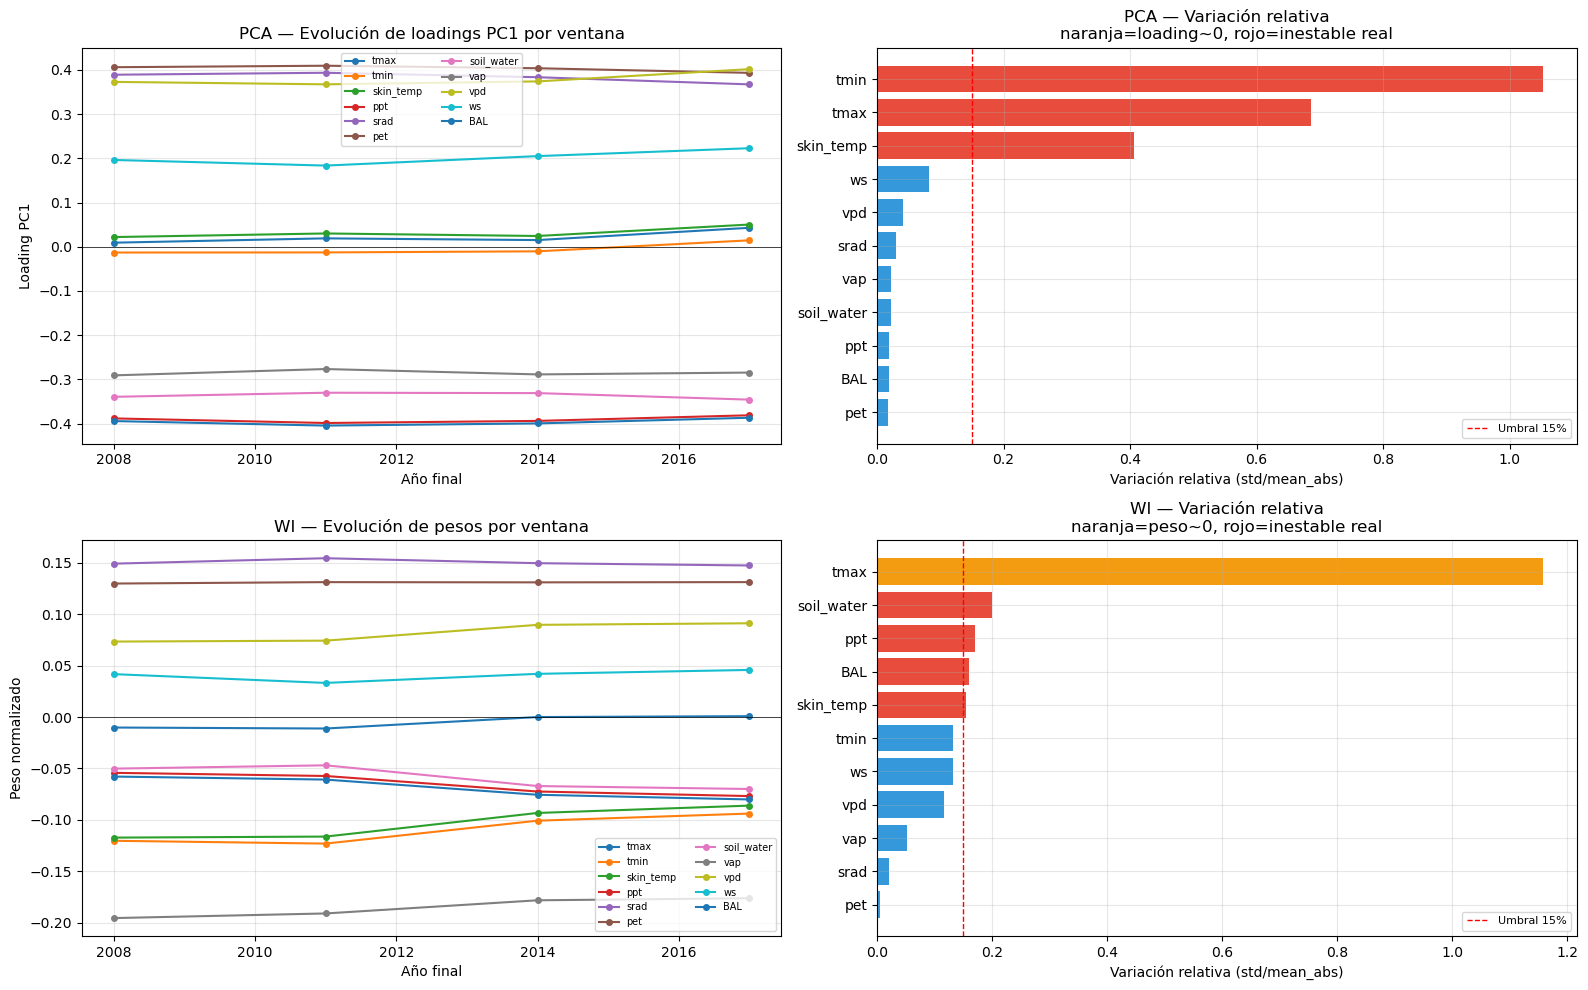


Loadings PCA por ventana:
      Z_tmax  Z_tmin  Z_skin_temp  Z_ppt  Z_srad  Z_pet  Z_soil_water  Z_vap  Z_vpd   Z_ws  Z_BAL
2008   0.009  -0.013        0.022 -0.388   0.389  0.406        -0.339 -0.291  0.373  0.196 -0.394
2011   0.019  -0.013        0.030 -0.398   0.393  0.409        -0.330 -0.277  0.367  0.184 -0.404
2014   0.015  -0.010        0.024 -0.394   0.383  0.404        -0.331 -0.289  0.374  0.205 -0.399
2017   0.043   0.015        0.050 -0.381   0.367  0.393        -0.346 -0.285  0.402  0.223 -0.387

Leyenda: azul=estable | naranja=rel>15% pero abs<0.01 (loading~0) | rojo=inestable real


In [8]:
# =====================================================================
# 2d. Diagnóstico visual — loadings PCA y pesos WI por ventana
# Colores: azul=estable | naranja=rel alta pero abs ~0 | rojo=inestable real
# =====================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# PCA: evolución
ax = axes[0, 0]
for col in COLS_Z:
    vals  = [l[col] for _, l in loadings_por_ventana_pca]
    anios = [fin for fin, _ in loadings_por_ventana_pca]
    ax.plot(anios, vals, marker='o', markersize=4,
            label=col.replace('Z_',''))
ax.axhline(0, color='black', linewidth=0.5)
ax.set_title('PCA — Evolución de loadings PC1 por ventana')
ax.set_xlabel('Año final'); ax.set_ylabel('Loading PC1')
ax.legend(fontsize=7, ncol=2); ax.grid(True, alpha=0.3)

# PCA: variación relativa
ax = axes[0, 1]
vars_ord = variacion_rel_pca.sort_values(ascending=True).index
colores  = ['#E74C3C' if (variacion_rel_pca[v]>0.15 and variacion_abs_pca[v]>0.01)
            else '#F39C12' if variacion_rel_pca[v]>0.15
            else '#3498DB' for v in vars_ord]
ax.barh(range(len(vars_ord)),
        [variacion_rel_pca[v] for v in vars_ord], color=colores)
ax.set_yticks(range(len(vars_ord)))
ax.set_yticklabels([v.replace('Z_','') for v in vars_ord])
ax.axvline(0.15, color='red', linestyle='--', linewidth=1, label='Umbral 15%')
ax.set_title('PCA — Variación relativa\n'
             'naranja=loading~0, rojo=inestable real')
ax.set_xlabel('Variación relativa (std/mean_abs)')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# WI: evolución
ax = axes[1, 0]
for col in COLS_Z:
    vals  = [p[col] for _, p in pesos_por_ventana_wi]
    anios = [fin for fin, _ in pesos_por_ventana_wi]
    ax.plot(anios, vals, marker='o', markersize=4,
            label=col.replace('Z_',''))
ax.axhline(0, color='black', linewidth=0.5)
ax.set_title('WI — Evolución de pesos por ventana')
ax.set_xlabel('Año final'); ax.set_ylabel('Peso normalizado')
ax.legend(fontsize=7, ncol=2); ax.grid(True, alpha=0.3)

# WI: variación relativa
ax = axes[1, 1]
vars_ord_wi = variacion_rel_wi.sort_values(ascending=True).index
colores_wi  = ['#E74C3C' if (variacion_rel_wi[v]>0.15 and variacion_abs_wi[v]>0.01)
               else '#F39C12' if variacion_rel_wi[v]>0.15
               else '#3498DB' for v in vars_ord_wi]
ax.barh(range(len(vars_ord_wi)),
        [variacion_rel_wi[v] for v in vars_ord_wi], color=colores_wi)
ax.set_yticks(range(len(vars_ord_wi)))
ax.set_yticklabels([v.replace('Z_','') for v in vars_ord_wi])
ax.axvline(0.15, color='red', linestyle='--', linewidth=1, label='Umbral 15%')
ax.set_title('WI — Variación relativa\n'
             'naranja=peso~0, rojo=inestable real')
ax.set_xlabel('Variación relativa (std/mean_abs)')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

print('\nLoadings PCA por ventana:')
print(df_load_pca.round(3).to_string())
print('\nLeyenda: azul=estable | naranja=rel>15% pero abs<0.01 (loading~0) | rojo=inestable real')


## 3. Pregunta analítica 2 — Dependencia IC ↔ NDVI_anom

Se usa el **IC completo** (no el residuo STL) porque:
- La pregunta es si el IC captura el estrés agrícola
- El NDVI_anom ya tiene removida su estacionalidad por DOY
- La STL se aplica **después** de seleccionar el IC, en la sección 4

**Selección basada en VAL. Test se usa solo una vez al final.**

**Métricas:** Recall ≥ 60% (buena cobertura) → Pinball loss


In [9]:
# =====================================================================
# 3.0  Estratificación por cobertura NDVI
# Las métricas de SELECCIÓN se calculan sobre VAL.
# Test se evalúa solo con el modelo ganador al final de 3d.
# =====================================================================

MESES_BAJA_COBERTURA = [3, 4, 10, 11]

for df in [df_train, df_val, df_test]:
    df['mes'] = df['fecha'].dt.month
    df['cobertura_ndvi'] = df['mes'].apply(
        lambda m: 'baja' if m in MESES_BAJA_COBERTURA else 'buena'
    )

NOMBRE_MES = {1:'Ene',2:'Feb',3:'Mar',4:'Abr',5:'May',6:'Jun',
              7:'Jul',8:'Ago',9:'Sep',10:'Oct',11:'Nov',12:'Dic'}

print('=== NDVI válido en VAL por estrato ===')
for estrato in ['buena', 'baja']:
    sub  = df_val[df_val['cobertura_ndvi'] == estrato]
    n_v  = sub['NDVI_anom'].notna().sum()
    p10n = df_train['NDVI_anom'].quantile(0.10)
    n_ex = (sub['NDVI_anom'].dropna() < p10n).sum()
    meses_s = ', '.join([NOMBRE_MES[m] for m in sorted(sub['mes'].unique())])
    print(f'\n  Estrato {estrato}:')
    print(f'    Meses       : {meses_s}')
    print(f'    Total filas : {len(sub):,}')
    print(f'    NDVI válido : {n_v:,} ({n_v/len(sub)*100:.1f}%)')
    print(f'    Extremos p10: {n_ex}')


=== NDVI válido en VAL por estrato ===

  Estrato buena:
    Meses       : Ene, Feb, May, Jun, Jul, Ago, Sep, Dic
    Total filas : 2,205
    NDVI válido : 1,180 (53.5%)
    Extremos p10: 95

  Estrato baja:
    Meses       : Mar, Abr, Oct, Nov
    Total filas : 1,127
    NDVI válido : 243 (21.6%)
    Extremos p10: 23


In [10]:
# =====================================================================
# 4a. Regresión cuantílica p10 (QR)
#
# Se ajusta en TRAIN y se evalúa en TEST.
# Métricas calculadas a nivel global y por estrato de cobertura NDVI.
# =====================================================================

TAU = 0.10

def metricas_estrato(df_test, col_ic, modelo, p10_ndvi, p10_ic, tau=0.10):
    """
    Calcula recall y pinball loss por estrato de cobertura NDVI.
    Retorna dict con metricas para 'buena' y 'baja'.
    """
    resultado = {}
    for estrato in ['buena', 'baja']:
        sub = df_test[
            (df_test['cobertura_ndvi'] == estrato) &
            df_test[[col_ic, 'NDVI_anom']].notna().all(axis=1)
        ]
        if len(sub) < 10:
            resultado[estrato] = {'n': len(sub), 'recall': None,
                                  'pinball': None, 'nota': 'insuficiente'}
            continue
        X    = sm.add_constant(sub[col_ic])
        pred = modelo.predict(X)
        err  = sub['NDVI_anom'].values - pred
        pinball  = np.mean(np.where(err >= 0, tau*err, (tau-1)*err))
        mask_ext = sub['NDVI_anom'] < p10_ndvi
        mask_ic  = sub[col_ic] < p10_ic
        recall   = (mask_ic[mask_ext]).mean()*100 if mask_ext.sum() > 0 else None
        resultado[estrato] = {
            'n'         : len(sub),
            'n_extremos': int(mask_ext.sum()),
            'recall'    : round(recall, 1) if recall is not None else None,
            'pinball'   : round(pinball, 4),
        }
    return resultado


def ajustar_qr(df_train, df_test, col_ic, tau=0.10):
    train_ok = df_train[[col_ic, 'NDVI_anom']].dropna()
    X_train  = sm.add_constant(train_ok[col_ic])
    y_train  = train_ok['NDVI_anom']
    modelo   = QuantReg(y_train, X_train).fit(q=tau, max_iter=2000)

    test_ok  = df_test[[col_ic, 'NDVI_anom']].dropna()
    X_test   = sm.add_constant(test_ok[col_ic])
    y_test   = test_ok['NDVI_anom']
    y_pred   = modelo.predict(X_test)

    # Métricas globales
    err      = y_test.values - y_pred
    pinball  = np.mean(np.where(err >= 0, tau*err, (tau-1)*err))
    cobertura = (y_test.values < y_pred).mean() * 100
    p10_ndvi = df_train['NDVI_anom'].quantile(0.10)
    p10_ic   = df_train[col_ic].quantile(0.10)
    mask_ext = test_ok['NDVI_anom'] < p10_ndvi
    mask_ic  = test_ok[col_ic] < p10_ic
    recall   = (mask_ic[mask_ext]).mean()*100 if mask_ext.sum() > 0 else np.nan

    # Métricas por estrato
    estratos = metricas_estrato(df_test, col_ic, modelo, p10_ndvi, p10_ic, tau)

    return modelo, y_pred, {
        'global': {
            'n_train'      : len(train_ok),
            'n_test'       : len(test_ok),
            'pinball'      : round(pinball, 4),
            'cobertura_p10': round(cobertura, 1),
            'recall'       : round(recall, 1) if not np.isnan(recall) else None,
            'n_extremos'   : int(mask_ext.sum()),
        },
        'estratos': estratos
    }


resultados_qr = {}
for col_ic in ['IC_PCA', 'IC_WI']:
    modelo, preds, metricas = ajustar_qr(df_train, df_val,  col_ic, TAU)
    resultados_qr[f'{col_ic}_QR'] = {'modelo': modelo, 'preds': preds,
                                      'metricas': metricas}
    print(f'\n{col_ic} + QR (tau=0.10):')
    print(f'  --- Global ---')
    for k, v in metricas['global'].items():
        print(f'    {k}: {v}')
    for estrato, m in metricas['estratos'].items():
        print(f'  --- Estrato {estrato} ---')
        for k, v in m.items():
            print(f'    {k}: {v}')



IC_PCA + QR (tau=0.10):
  --- Global ---
    n_train: 8829
    n_test: 1423
    pinball: 0.1961
    cobertura_p10: 7.8
    recall: 2.5
    n_extremos: 118
  --- Estrato buena ---
    n: 1180
    n_extremos: 95
    recall: 3.2
    pinball: 0.2001
  --- Estrato baja ---
    n: 243
    n_extremos: 23
    recall: 0.0
    pinball: 0.1766

IC_WI + QR (tau=0.10):
  --- Global ---
    n_train: 8829
    n_test: 1423
    pinball: 0.1774
    cobertura_p10: 8.4
    recall: 34.7
    n_extremos: 118
  --- Estrato buena ---
    n: 1180
    n_extremos: 95
    recall: 36.8
    pinball: 0.1798
  --- Estrato baja ---
    n: 243
    n_extremos: 23
    recall: 26.1
    pinball: 0.1658


In [11]:
# =====================================================================
# 4b. OLS sobre eventos extremos
#
# Filtrar IC < p20 (zona de estrés). Ajustar OLS en TRAIN.
# Métricas calculadas a nivel global y por estrato de cobertura NDVI.
# =====================================================================

UMBRAL_OLS = 0.20

def ajustar_ols_extremos(df_train, df_test, col_ic, umbral=0.20):
    p_umbral = df_train[col_ic].quantile(umbral)
    p10_ndvi = df_train['NDVI_anom'].quantile(0.10)
    p10_ic   = df_train[col_ic].quantile(0.10)

    train_ok  = df_train[[col_ic, 'NDVI_anom']].dropna()
    train_ext = train_ok[train_ok[col_ic] < p_umbral]
    X_train   = sm.add_constant(train_ext[col_ic])
    modelo    = sm.OLS(train_ext['NDVI_anom'], X_train).fit()

    test_ok   = df_test[[col_ic, 'NDVI_anom']].dropna()

    # R² sobre extremos del test
    test_ext = test_ok[test_ok[col_ic] < p_umbral]
    r2_ext   = np.nan
    if len(test_ext) > 2:
        preds_ext = modelo.predict(sm.add_constant(test_ext[col_ic]))
        ss_res = ((test_ext['NDVI_anom'].values - preds_ext)**2).sum()
        ss_tot = ((test_ext['NDVI_anom'].values - test_ext['NDVI_anom'].mean())**2).sum()
        r2_ext = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan

    # Pinball y recall globales
    y_pred_all = modelo.predict(sm.add_constant(test_ok[col_ic]))
    err        = test_ok['NDVI_anom'].values - y_pred_all
    pinball    = np.mean(np.where(err >= 0, TAU*err, (TAU-1)*err))
    mask_ext   = test_ok['NDVI_anom'] < p10_ndvi
    mask_ic    = test_ok[col_ic] < p10_ic
    recall     = (mask_ic[mask_ext]).mean()*100 if mask_ext.sum() > 0 else np.nan

    # Métricas por estrato
    estratos = metricas_estrato(df_test, col_ic, modelo, p10_ndvi, p10_ic, TAU)

    return modelo, {
        'global': {
            'n_train_ext' : len(train_ext),
            'n_test'      : len(test_ok),
            'r2_extremos' : round(r2_ext, 3) if not np.isnan(r2_ext) else None,
            'pinball'     : round(pinball, 4),
            'recall'      : round(recall, 1) if not np.isnan(recall) else None,
            'n_extremos'  : int(mask_ext.sum()),
        },
        'estratos': estratos
    }


resultados_ols = {}
for col_ic in ['IC_PCA', 'IC_WI']:
    modelo, metricas = ajustar_ols_extremos(df_train, df_val,  col_ic, UMBRAL_OLS)
    resultados_ols[f'{col_ic}_OLS'] = {'modelo': modelo, 'metricas': metricas}
    print(f'\n{col_ic} + OLS (p{int(UMBRAL_OLS*100)} extremos):')
    print(f'  --- Global ---')
    for k, v in metricas['global'].items():
        print(f'    {k}: {v}')
    for estrato, m in metricas['estratos'].items():
        print(f'  --- Estrato {estrato} ---')
        for k, v in m.items():
            print(f'    {k}: {v}')



IC_PCA + OLS (p20 extremos):
  --- Global ---
    n_train_ext: 1837
    n_test: 1423
    r2_extremos: 0.061
    pinball: 0.273
    recall: 2.5
    n_extremos: 118
  --- Estrato buena ---
    n: 1180
    n_extremos: 95
    recall: 3.2
    pinball: 0.283
  --- Estrato baja ---
    n: 243
    n_extremos: 23
    recall: 0.0
    pinball: 0.2244

IC_WI + OLS (p20 extremos):
  --- Global ---
    n_train_ext: 2102
    n_test: 1423
    r2_extremos: -0.004
    pinball: 0.4489
    recall: 34.7
    n_extremos: 118
  --- Estrato buena ---
    n: 1180
    n_extremos: 95
    recall: 36.8
    pinball: 0.4412
  --- Estrato baja ---
    n: 243
    n_extremos: 23
    recall: 26.1
    pinball: 0.4864


In [12]:
# =====================================================================
# 3d. Selección del IC definitivo (basada en VAL)
#
# Criterios de selección en orden de prioridad:
# 1. Recall >= 60% en estrato buena cobertura (criterio primario, R5)
# 2. Menor pinball loss (criterio comparativo entre alternativas)
# 3. Empate pinball: priorizar QR sobre OLS (mayor rigor metodológico)
# 4. Empate QR: priorizar WI sobre PCA (mayor interpretabilidad, R10)
# 5. Refuerzo: si QR además supera cobertura empírica p10 = 10%±2pp (R5),
#    eso refuerza su selección pero no es criterio de descarte.
#
# Si ninguna combinación alcanza recall >= 60%: el problema está en el IC,
# no en el método de dependencia. Revisar construcción antes de continuar.
# =====================================================================

filas = []
for nombre, res in {**resultados_qr, **resultados_ols}.items():
    mg = res['metricas']['global']
    mb = res['metricas']['estratos'].get('buena', {})
    ml = res['metricas']['estratos'].get('baja',  {})
    recall_b = mb.get('recall')
    # Verificar cobertura empírica p10 (solo aplica a QR)
    cob_p10  = mg.get('cobertura_p10', None)
    r5_ok    = '✅' if cob_p10 is not None and abs(cob_p10 - 10) <= 2 else '—'
    filas.append({
        'Combinacion'               : nombre,
        'Recall global VAL (%)'     : mg.get('recall'),
        'Recall buena cob. VAL (%)'  : recall_b,
        'Recall baja cob. VAL (%)'   : ml.get('recall'),
        'Pinball VAL'               : mg.get('pinball'),
        'Cob.p10 / R²'             : cob_p10 if cob_p10 else mg.get('r2_extremos','—'),
        'R5 cob. OK'               : r5_ok,
        'N extremos VAL'            : mg.get('n_extremos'),
        'OK'                        : '✅' if (recall_b or 0) >= 60 else '❌'
    })

df_resultados = pd.DataFrame(filas).set_index('Combinacion')
print('=== TABLA COMPARATIVA — VAL SET ===')
print(df_resultados.to_string())

candidatos = df_resultados[df_resultados['OK'] == '✅']

if len(candidatos) == 0:
    print('\n❌ Ninguna combinación alcanza recall >= 60% en VAL.')
    print('   El problema está en el IC, no en el método de dependencia.')
    print('   Un IC que no captura bien el estrés climático no puede producir')
    print('   una buena relación con el NDVI independientemente del método.')
    print('   → Revisar construcción del IC antes de continuar.')
    IC_SELECCIONADO = None
    METODO_DEP      = None
else:
    # Paso 1: minimizar pinball loss entre candidatos con recall >= 60%
    mejor_pinball = candidatos['Pinball VAL'].astype(float).idxmin()
    pinball_min   = candidatos.loc[mejor_pinball, 'Pinball VAL']

    # Paso 2: verificar empate (diferencia < 0.001 en pinball)
    empate = candidatos[
        (candidatos['Pinball VAL'].astype(float) - float(pinball_min)).abs() < 0.001
    ]

    if len(empate) > 1:
        print(f'\nEmpate en pinball loss ({len(empate)} combinaciones).')
        print('Aplicando criterios de desempate:')
        # Desempate 1: priorizar QR
        empate_qr = empate[empate.index.str.endswith('_QR')]
        if len(empate_qr) > 0:
            empate = empate_qr
            print('  → Criterio 1: QR priorizado sobre OLS ✅')
        # Desempate 2: priorizar WI sobre PCA
        empate_wi = empate[empate.index.str.contains('WI')]
        if len(empate_wi) > 0:
            empate = empate_wi
            print('  → Criterio 2: WI priorizado sobre PCA (mayor interpretabilidad R10) ✅')
        mejor = empate['Pinball VAL'].astype(float).idxmin()
    else:
        mejor = mejor_pinball

    IC_SELECCIONADO = '_'.join(mejor.split('_')[:-1]).replace('IC_', '')
    METODO_DEP      = mejor.split('_')[-1]

    print(f'\n✅ Seleccionado (VAL): {mejor}')
    print(f'   IC definitivo       : IC_{IC_SELECCIONADO}')
    print(f'   Método dep.         : {METODO_DEP}')
    print(f'   Recall buena VAL    : {df_resultados.loc[mejor,"Recall buena cob. VAL (%)"]}%')
    print(f'   Pinball VAL         : {df_resultados.loc[mejor,"Pinball VAL"]}')

    # Refuerzo R5: cobertura empírica p10
    r5_val = df_resultados.loc[mejor, 'R5 cob. OK']
    if r5_val == '✅':
        print(f'   Cobertura empírica p10: dentro de 10%±2pp ✅ (refuerza selección)')
    elif METODO_DEP == 'QR':
        print(f'   Cobertura empírica p10: fuera de 10%±2pp ⚠️ (no descarta, solo nota)')

    # ── Evaluación final sobre TEST ───────────────────────────────────
    print('\n=== EVALUACIÓN FINAL — TEST SET ===')
    print('(Solo el modelo ganador — primera y única evaluación en test)')
    if METODO_DEP == 'QR':
        _, _, mt = ajustar_qr(df_train, df_test, f'IC_{IC_SELECCIONADO}', TAU)
    else:
        _, mt = ajustar_ols_extremos(df_train, df_test,
                                      f'IC_{IC_SELECCIONADO}', UMBRAL_OLS)
    print('\n  Métricas globales (TEST):')
    for k, v in mt['global'].items():
        print(f'    {k}: {v}')
    print('\n  Por estrato de cobertura NDVI (TEST):')
    for est, m in mt['estratos'].items():
        print(f'    {est}: {m}')

    for df in [df_train, df_val, df_test]:
        df['IC'] = df[f'IC_{IC_SELECCIONADO}']

    df_resultados.to_csv('output_ic/resultados_pa2_val.csv')
    print('\n✅ Tabla guardada. IC asignado.')


=== TABLA COMPARATIVA — VAL SET ===
             Recall global VAL (%)  Recall buena cob. VAL (%)  Recall baja cob. VAL (%)  Pinball VAL  Cob.p10 / R² R5 cob. OK  N extremos VAL OK
Combinacion                                                                                                                                     
IC_PCA_QR                      2.5                        3.2                       0.0       0.1961         7.800          —             118  ❌
IC_WI_QR                      34.7                       36.8                      26.1       0.1774         8.400          ✅             118  ❌
IC_PCA_OLS                     2.5                        3.2                       0.0       0.2730         0.061          —             118  ❌
IC_WI_OLS                     34.7                       36.8                      26.1       0.4489        -0.004          —             118  ❌

❌ Ninguna combinación alcanza recall >= 60% en VAL.
   El problema está en el IC, no en el mé

In [13]:
# =====================================================================
# 3e. Sensibilidad del recall al umbral del trigger
#
# El recall calculado en 3b y 3c usa p10_ic como umbral del trigger,
# es decir, activa el pago cuando IC < p10.
# Este bloque evalúa cómo varía el recall si se relaja o ajusta
# ese umbral (p5 a p25), y la precisión correspondiente.
#
# Recall    = proporción de eventos NDVI extremos que el IC detecta
# Precisión = proporción de activaciones del trigger que coinciden
#             con eventos NDVI extremos reales
#
# El balance recall/precisión es una decisión actuarial:
#   - Recall alto = más siniestros cubiertos, pero más pagos sin pérdida real
#   - Precisión alta = menos pagos injustificados, pero más siniestros sin cubrir
#
# Se evalúa sobre VAL con el IC seleccionado. Si ningún umbral alcanza
# recall >= 60%, se documenta como limitación estructural del modelo.
# =====================================================================

if IC_SELECCIONADO is not None:
    col_ic_sel = f'IC_{IC_SELECCIONADO}'

    val_valido = df_val[[col_ic_sel, 'NDVI_anom']].dropna()
    p10_ndvi   = df_train['NDVI_anom'].quantile(0.10)
    mask_ext   = val_valido['NDVI_anom'] < p10_ndvi

    print(f"=== SENSIBILIDAD DEL RECALL AL UMBRAL DEL TRIGGER ===")
    print(f"IC seleccionado : {col_ic_sel}")
    print(f"Eventos NDVI extremos en VAL (p10): {mask_ext.sum()}")
    print(f"{'Umbral IC':<12} {'Recall':>8} {'Precisión':>10} "
          f"{'Activaciones':>13} {'F1':>8}")
    print("─" * 58)

    resultados_umbral = []
    for pct in [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]:
        umbral_ic = df_train[col_ic_sel].quantile(pct)
        mask_ic   = val_valido[col_ic_sel] < umbral_ic
        n_act     = mask_ic.sum()

        recall_p  = (mask_ic & mask_ext).sum() / mask_ext.sum() * 100                     if mask_ext.sum() > 0 else 0
        precision = (mask_ic & mask_ext).sum() / n_act * 100                     if n_act > 0 else 0
        f1 = 2 * recall_p * precision / (recall_p + precision)              if (recall_p + precision) > 0 else 0

        marca = ' ← umbral actual' if pct == 0.10 else ''
        marca = ' ✅ recall >= 60%' if recall_p >= 60 else marca
        print(f"  p{int(pct*100):02d}         {recall_p:>7.1f}% {precision:>9.1f}% "
              f"{n_act:>12,}  {f1:>7.1f}{marca}")

        resultados_umbral.append({
            'pct': pct, 'recall': recall_p,
            'precision': precision, 'n_activaciones': n_act, 'f1': f1
        })

    # Umbral con mejor F1
    df_umbral = pd.DataFrame(resultados_umbral)
    mejor_f1  = df_umbral.loc[df_umbral['f1'].idxmax()]
    mejor_rec = df_umbral.loc[df_umbral['recall'].idxmax()]

    print(f"\n  Mejor F1    : p{int(mejor_f1['pct']*100):02d} → "
          f"recall={mejor_f1['recall']:.1f}%  "
          f"precisión={mejor_f1['precision']:.1f}%  "
          f"F1={mejor_f1['f1']:.1f}")
    print(f"  Mejor recall: p{int(mejor_rec['pct']*100):02d} → "
          f"recall={mejor_rec['recall']:.1f}%  "
          f"precisión={mejor_rec['precision']:.1f}%")

    # Visualización
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    pcts   = [r['pct']*100 for r in resultados_umbral]
    recalls = [r['recall'] for r in resultados_umbral]
    precs   = [r['precision'] for r in resultados_umbral]
    f1s     = [r['f1'] for r in resultados_umbral]

    ax = axes[0]
    ax.plot(pcts, recalls,   marker='o', label='Recall',    color='#E74C3C')
    ax.plot(pcts, precs,     marker='s', label='Precisión', color='#3498DB')
    ax.plot(pcts, f1s,       marker='^', label='F1',        color='#2ECC71')
    ax.axhline(60, color='red', linestyle='--', linewidth=1, label='Recall 60%')
    ax.axvline(10, color='gray', linestyle=':', linewidth=1, label='Umbral actual (p10)')
    ax.set_xlabel('Percentil umbral del IC (%)')
    ax.set_ylabel('Métrica (%)')
    ax.set_title(f'Recall / Precisión / F1 por umbral\n{col_ic_sel} — VAL set')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xticks([int(p*100) for p in [0.05,0.10,0.15,0.20,0.25,0.30]])

    ax = axes[1]
    ax.bar(pcts, [r['n_activaciones'] for r in resultados_umbral],
           color='#9B59B6', alpha=0.7)
    ax.set_xlabel('Percentil umbral del IC (%)')
    ax.set_ylabel('N° activaciones del trigger')
    ax.set_title('Activaciones del trigger por umbral\n(cuántas veces pagaría el seguro)')
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_xticks([int(p*100) for p in [0.05,0.10,0.15,0.20,0.25,0.30]])

    plt.tight_layout()
    plt.show()

    # Interpretación
    print("\n=== INTERPRETACIÓN ACTUARIAL ===")
    alcanza_60 = df_umbral[df_umbral['recall'] >= 60]
    if len(alcanza_60) > 0:
        print(f"✅ Existen umbrales que alcanzan recall >= 60%:")
        for _, row in alcanza_60.iterrows():
            print(f"   p{int(row['pct']*100):02d}: recall={row['recall']:.1f}%  "
                  f"precisión={row['precision']:.1f}%  "
                  f"activaciones={int(row['n_activaciones'])}")
        print("\n   Decisión: el equipo actuarial debe elegir el balance")
        print("   recall/precisión según la política de la aseguradora.")
    else:
        print("⚠️  Ningún umbral alcanza recall >= 60% en VAL.")
        print(f"   Recall máximo alcanzable: {mejor_rec['recall']:.1f}% "
              f"(p{int(mejor_rec['pct']*100):02d})")
        print("\n   Esto indica una limitación estructural del modelo con")
        print("   estos datos: el IC captura parte de la señal de estrés")
        print("   agrícola pero no toda. Causas probables:")
        print("   1. Alta nubosidad en Caldas → NDVI con ~50% faltante")
        print("   2. Heterogeneidad topográfica dentro de celdas de 10km")
        print("   3. El clima de Caldas tiene variabilidad subregional que")
        print("      una celda ERA5 no puede capturar completamente")
        print("\n   Se documenta como limitación en el reporte de modelos.")
        print("   Mejoras propuestas para V2: datos de campo a nivel finca,")
        print("   Sentinel-2 (10m) como proxy de pérdida más preciso.")
else:
    print("IC_SELECCIONADO no definido. Ejecutar celda 3d primero.")


IC_SELECCIONADO no definido. Ejecutar celda 3d primero.


## 3f. Alternativas de IC para mejorar el recall

Dado que el recall con IC_PCA e IC_WI base está por debajo del umbral (60%),
se exploran cuatro alternativas de construcción rápida:

| Alt. | Descripción | Tiempo est. |
|------|-------------|-------------|
| **IC_WI_top5** | WI con solo las 5 variables de mayor correlación con NDVI_anom | 30 min |
| **IC_WI_ext** | WI con pesos calculados solo sobre observaciones de estrés (p20) | 45 min |
| **IC_WI_min2** | Mínimo del IC_WI en ventana de 2 períodos (persistencia del estrés) | 20 min |
| **IC_WI_elev** | IC_WI calculado por estrato de elevación | 60 min |

Al final se genera una tabla comparativa de todas las combinaciones IC × método.


In [14]:
# =====================================================================
# 3f.1  Construcción de ICs alternativos
# =====================================================================

# ── ALT 1: IC_WI_top5 — solo las 5 variables de mayor correlación ────
print("=== ALT 1: IC_WI_top5 ===")
top5_vars = corr_series.abs().nlargest(5).index.tolist()
print(f"Variables seleccionadas: {[v.replace('Z_','') for v in top5_vars]}")

pesos_top5 = corr_series[top5_vars]
pesos_top5 = pesos_top5 / pesos_top5.abs().sum()
print(f"Pesos: {pesos_top5.round(3).to_dict()}")

def aplicar_wi_subset(df, pesos, cols):
    df = df.copy()
    mask = df[cols].notna().all(axis=1)
    ic   = np.full(len(df), np.nan)
    if mask.sum() > 0:
        ic[mask] = df.loc[mask, cols].values @ pesos[cols].values
    df['IC_WI_top5'] = ic
    return df

df_train = aplicar_wi_subset(df_train, pesos_top5, top5_vars)
df_val   = aplicar_wi_subset(df_val,   pesos_top5, top5_vars)
df_test  = aplicar_wi_subset(df_test,  pesos_top5, top5_vars)

# Verificar correlación
tv = df_train[['IC_WI_top5','NDVI_anom']].dropna()
r, _ = stats.spearmanr(tv['IC_WI_top5'], tv['NDVI_anom'])
print(f"Correlación IC_WI_top5 ↔ NDVI_anom (train): ρ = {r:.4f}")

# ── ALT 2: IC_WI_ext — pesos calculados sobre extremos (NDVI < p20) ──
print("\n=== ALT 2: IC_WI_ext ===")
p20_ndvi = df_train['NDVI_anom'].quantile(0.20)
train_ext_mask = df_train['NDVI_anom'] < p20_ndvi
train_ext = df_train.loc[train_ext_mask, COLS_Z + ['NDVI_anom']].dropna()
print(f"Observaciones de estrés en train (NDVI_anom < p20): {len(train_ext):,}")

corr_ext = {c: stats.spearmanr(train_ext[c],
             train_ext['NDVI_anom'])[0] for c in COLS_Z}
pesos_ext = pd.Series(corr_ext)
pesos_ext = pesos_ext / pesos_ext.abs().sum()
print(f"Pesos sobre extremos (top 5):")
print(pesos_ext.abs().nlargest(5).round(3).to_string())

def aplicar_wi_ext(df, pesos, cols):
    df = df.copy()
    mask = df[cols].notna().all(axis=1)
    ic   = np.full(len(df), np.nan)
    if mask.sum() > 0:
        ic[mask] = df.loc[mask, cols].values @ pesos[cols].values
    df['IC_WI_ext'] = ic
    return df

df_train = aplicar_wi_ext(df_train, pesos_ext, COLS_Z)
df_val   = aplicar_wi_ext(df_val,   pesos_ext, COLS_Z)
df_test  = aplicar_wi_ext(df_test,  pesos_ext, COLS_Z)

tv = df_train[['IC_WI_ext','NDVI_anom']].dropna()
r, _ = stats.spearmanr(tv['IC_WI_ext'], tv['NDVI_anom'])
print(f"Correlación IC_WI_ext ↔ NDVI_anom (train): ρ = {r:.4f}")

# ── ALT 3: IC_WI_min2 — mínimo móvil de 2 períodos ──────────────────
print("\n=== ALT 3: IC_WI_min2 ===")
print("Mínimo del IC_WI en ventana de 2 períodos consecutivos (32 días)")
print("Captura persistencia del estrés climático")

for df in [df_train, df_val, df_test]:
    df['IC_WI_min2'] = (
        df.sort_values(['lat', 'lon', 'fecha'])
          .groupby(['lat', 'lon'])['IC_WI']
          .transform(lambda x: x.rolling(2, min_periods=1).min())
    )

tv = df_train[['IC_WI_min2','NDVI_anom']].dropna()
r, _ = stats.spearmanr(tv['IC_WI_min2'], tv['NDVI_anom'])
print(f"Correlación IC_WI_min2 ↔ NDVI_anom (train): ρ = {r:.4f}")

# ── ALT 4: IC_WI_elev — por estrato de elevación ─────────────────────
print("\n=== ALT 4: IC_WI_elev ===")
if 'elevacion' in df_train.columns:
    for df in [df_train, df_val, df_test]:
        df['estrato_elev'] = pd.cut(
            df['elevacion'],
            bins=[1200, 1500, 1800],
            labels=['bajo', 'alto']
        )

    pesos_elev = {}
    for estrato in ['bajo', 'alto']:
        sub = df_train[df_train['estrato_elev'] == estrato]
        sub_ok = sub[COLS_Z + ['NDVI_anom']].dropna()
        if len(sub_ok) < 30:
            print(f"  Estrato {estrato}: insuficientes observaciones ({len(sub_ok)})")
            continue
        corr_e = {c: stats.spearmanr(sub_ok[c],
                  sub_ok['NDVI_anom'])[0] for c in COLS_Z}
        p_e = pd.Series(corr_e)
        p_e = p_e / p_e.abs().sum()
        pesos_elev[estrato] = p_e
        r_e, _ = stats.spearmanr(sub_ok[COLS_Z].values @ p_e[COLS_Z].values,
                                   sub_ok['NDVI_anom'])
        n_ext_e = (sub_ok['NDVI_anom'] < df_train['NDVI_anom'].quantile(0.10)).sum()
        print(f"  Estrato {estrato}: ρ={r_e:.4f} | n_obs={len(sub_ok):,} | extremos={n_ext_e}")

    if pesos_elev:
        for df in [df_train, df_val, df_test]:
            df['IC_WI_elev'] = np.nan
            for estrato, p_e in pesos_elev.items():
                mask_e = (df['estrato_elev'] == estrato) &                           df[COLS_Z].notna().all(axis=1)
                if mask_e.sum() > 0:
                    df.loc[mask_e, 'IC_WI_elev'] = (
                        df.loc[mask_e, COLS_Z].values @ p_e[COLS_Z].values
                    )
        tv = df_train[['IC_WI_elev','NDVI_anom']].dropna()
        r, _ = stats.spearmanr(tv['IC_WI_elev'], tv['NDVI_anom'])
        print(f"  Correlación IC_WI_elev ↔ NDVI_anom (train): ρ = {r:.4f}")
    else:
        print("  IC_WI_elev no disponible: datos insuficientes por estrato")
        for df in [df_train, df_val, df_test]:
            df['IC_WI_elev'] = np.nan
else:
    print("  Columna 'elevacion' no disponible en los DataFrames.")
    print("  Omitiendo ALT 4.")
    for df in [df_train, df_val, df_test]:
        df['IC_WI_elev'] = np.nan

# Resumen de correlaciones
print("\n=== RESUMEN DE CORRELACIONES CON NDVI_anom (train) ===")
ics_todos = ['IC_PCA', 'IC_WI', 'IC_WI_top5', 'IC_WI_ext',
             'IC_WI_min2', 'IC_WI_elev']
for col in ics_todos:
    if col in df_train.columns:
        tv = df_train[[col, 'NDVI_anom']].dropna()
        if len(tv) > 10:
            r, _ = stats.spearmanr(tv[col], tv['NDVI_anom'])
            print(f"  {col:<15}: ρ = {r:.4f}  (n={len(tv):,})")
        else:
            print(f"  {col:<15}: insuficientes datos")


=== ALT 1: IC_WI_top5 ===
Variables seleccionadas: ['vap', 'srad', 'pet', 'vpd', 'tmin']
Pesos: {'Z_vap': -0.277, 'Z_srad': 0.228, 'Z_pet': 0.203, 'Z_vpd': 0.147, 'Z_tmin': -0.144}


Correlación IC_WI_top5 ↔ NDVI_anom (train): ρ = 0.5401

=== ALT 2: IC_WI_ext ===
Observaciones de estrés en train (NDVI_anom < p20): 1,766
Pesos sobre extremos (top 5):
Z_tmin         0.22
Z_skin_temp    0.20
Z_vap          0.17
Z_srad         0.12
Z_ppt          0.09
Correlación IC_WI_ext ↔ NDVI_anom (train): ρ = 0.3707

=== ALT 3: IC_WI_min2 ===
Mínimo del IC_WI en ventana de 2 períodos consecutivos (32 días)
Captura persistencia del estrés climático
Correlación IC_WI_min2 ↔ NDVI_anom (train): ρ = 0.4904

=== ALT 4: IC_WI_elev ===
  Columna 'elevacion' no disponible en los DataFrames.
  Omitiendo ALT 4.

=== RESUMEN DE CORRELACIONES CON NDVI_anom (train) ===
  IC_PCA         : ρ = 0.3465  (n=8,829)
  IC_WI          : ρ = 0.4952  (n=8,829)
  IC_WI_top5     : ρ = 0.5401  (n=8,829)
  IC_WI_ext      : ρ = 0.3707  (n=8,829)
  IC_WI_min2     : ρ = 0.4904  (n=8,829)
  IC_WI_elev     : insuficientes datos


Omitiendo IC_WI_elev: insuficientes datos en VAL
ICs a evaluar: ['IC_PCA', 'IC_WI', 'IC_WI_top5', 'IC_WI_ext', 'IC_WI_min2']

Ajustando QR...
  IC_PCA_QR: recall_buena=3.2%  pinball=0.1961
  IC_WI_QR: recall_buena=36.8%  pinball=0.1774
  IC_WI_top5_QR: recall_buena=38.9%  pinball=0.1715
  IC_WI_ext_QR: recall_buena=71.6%  pinball=0.1699
  IC_WI_min2_QR: recall_buena=36.8%  pinball=0.1809

Ajustando OLS...
  IC_PCA_OLS: recall_buena=3.2%  pinball=0.273
  IC_WI_OLS: recall_buena=36.8%  pinball=0.4489
  IC_WI_top5_OLS: recall_buena=38.9%  pinball=0.6205
  IC_WI_ext_OLS: recall_buena=71.6%  pinball=0.8334
  IC_WI_min2_OLS: recall_buena=36.8%  pinball=0.5896

TABLA COMPARATIVA COMPLETA — VAL SET
                Recall global (%)  Recall buena cob. (%)  Recall baja cob. (%)  Pinball loss  Cob.p10 / R²  N extremos VAL Recall >= 60%
Combinación                                                                                                                             
IC_WI_ext_OLS             

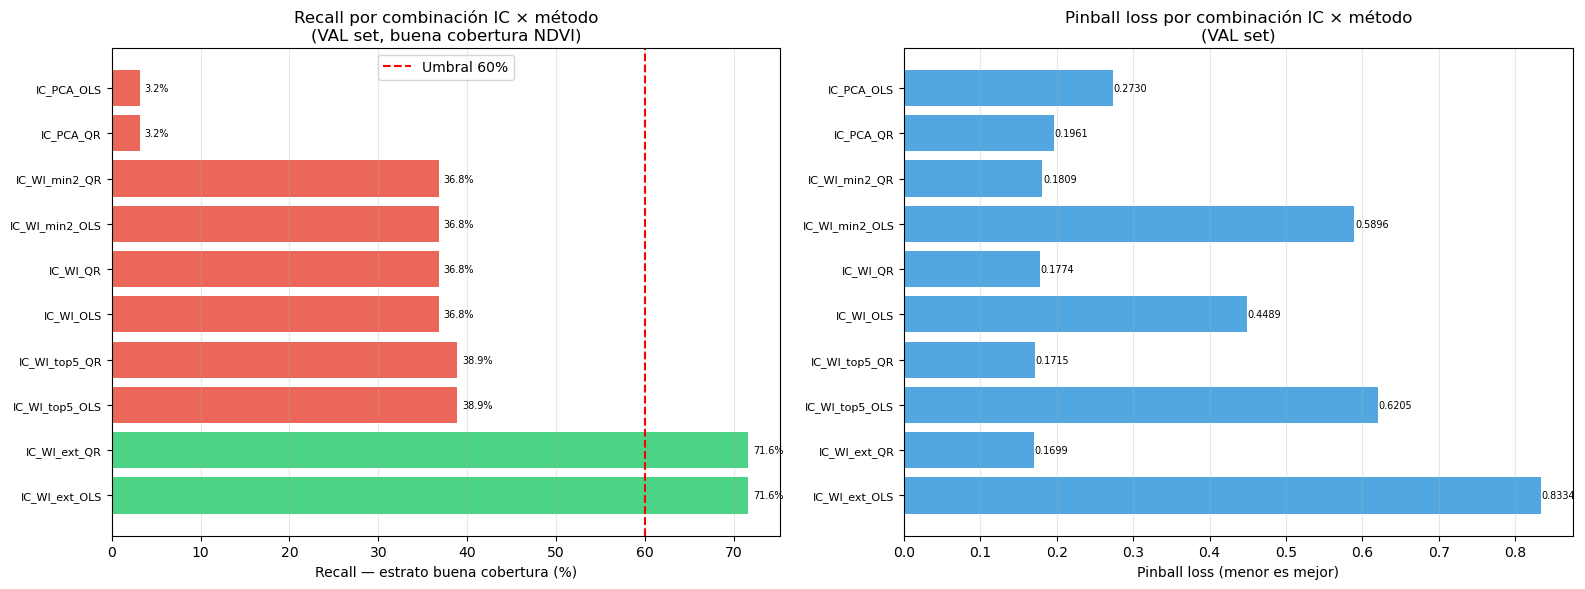


=== SELECCIÓN FINAL — TODOS LOS CRITERIOS ===
Criterios en orden:
  1. Recall >= 60% en buena cobertura (R5)
  2. Menor pinball loss
  3. Empate: QR > OLS (rigor metodológico)
  4. Empate: WI > PCA (interpretabilidad, R10)
  5. Refuerzo: QR con cobertura empírica p10 = 10%±2pp (R5)

✅ Combinación ganadora: IC_WI_ext_QR
   Recall buena cob.: 71.6%
   Pinball loss     : 0.1699
   Cobertura empírica p10: 7.2% ⚠️ fuera de 10%±2pp (no descarta)

   IC definitivo : IC_WI_ext
   Método dep.   : QR

✅ IC_SELECCIONADO='IC_WI_ext' | METODO_DEP='QR'


In [15]:
# =====================================================================
# 3f.2  Evaluación de todas las combinaciones IC × método
#
# Se evalúan todas las combinaciones disponibles:
#   ICs: IC_PCA, IC_WI, IC_WI_top5, IC_WI_ext, IC_WI_min2, IC_WI_elev
#   Métodos: QR (regresión cuantílica p10), OLS (sobre extremos p20)
#
# Métricas sobre VAL set:
#   - Recall (estrato buena cobertura) — criterio primario
#   - Pinball loss global
#   - Cobertura empírica p10 (QR) / R² extremos (OLS)
#   - N extremos evaluados
#
# Test se usa solo con el IC+método ganador al final.
# =====================================================================

# ICs a evaluar (excluir los que tienen todos NaN)
ICS_EVALUAR = []
for col in ['IC_PCA', 'IC_WI', 'IC_WI_top5', 'IC_WI_ext',
            'IC_WI_min2', 'IC_WI_elev']:
    if col in df_val.columns and df_val[col].notna().sum() > 50:
        ICS_EVALUAR.append(col)
    else:
        print(f"Omitiendo {col}: insuficientes datos en VAL")

print(f"ICs a evaluar: {ICS_EVALUAR}")

# ── Correr QR para todos los ICs ─────────────────────────────────────
print("\nAjustando QR...")
resultados_qr_ext = {}
for col_ic in ICS_EVALUAR:
    try:
        modelo, preds, metricas = ajustar_qr(df_train, df_val, col_ic, TAU)
        resultados_qr_ext[f'{col_ic}_QR'] = {
            'modelo': modelo, 'preds': preds, 'metricas': metricas
        }
        print(f"  {col_ic}_QR: recall_buena={metricas['estratos']['buena'].get('recall','N/A')}%  "
              f"pinball={metricas['global']['pinball']}")
    except Exception as e:
        print(f"  {col_ic}_QR: ERROR — {e}")

# ── Correr OLS para todos los ICs ─────────────────────────────────────
print("\nAjustando OLS...")
resultados_ols_ext = {}
for col_ic in ICS_EVALUAR:
    try:
        modelo, metricas = ajustar_ols_extremos(df_train, df_val,
                                                 col_ic, UMBRAL_OLS)
        resultados_ols_ext[f'{col_ic}_OLS'] = {
            'modelo': modelo, 'metricas': metricas
        }
        print(f"  {col_ic}_OLS: recall_buena={metricas['estratos']['buena'].get('recall','N/A')}%  "
              f"pinball={metricas['global']['pinball']}")
    except Exception as e:
        print(f"  {col_ic}_OLS: ERROR — {e}")

# ── Tabla comparativa completa ─────────────────────────────────────────
print("\n" + "="*70)
print("TABLA COMPARATIVA COMPLETA — VAL SET")
print("="*70)

filas_ext = []
for nombre, res in {**resultados_qr_ext, **resultados_ols_ext}.items():
    mg = res['metricas']['global']
    mb = res['metricas']['estratos'].get('buena', {})
    ml = res['metricas']['estratos'].get('baja',  {})
    recall_b = mb.get('recall')
    filas_ext.append({
        'Combinación'              : nombre,
        'Recall global (%)'        : mg.get('recall'),
        'Recall buena cob. (%)'   : recall_b,
        'Recall baja cob. (%)'    : ml.get('recall'),
        'Pinball loss'             : mg.get('pinball'),
        'Cob.p10 / R²'            : mg.get('cobertura_p10',
                                            mg.get('r2_extremos', '—')),
        'N extremos VAL'           : mg.get('n_extremos'),
        'Recall >= 60%'            : '✅' if (recall_b or 0) >= 60 else '❌'
    })

df_comp = (pd.DataFrame(filas_ext)
             .set_index('Combinación')
             .sort_values('Recall buena cob. (%)', ascending=False))

print(df_comp.to_string())

# ── Visualización ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

combis    = df_comp.index.tolist()
recalls_b = df_comp['Recall buena cob. (%)'].fillna(0).tolist()
pinballs  = df_comp['Pinball loss'].astype(float).tolist()
colores   = ['#2ECC71' if r >= 60 else '#E74C3C' for r in recalls_b]

# Recall por combinación
ax = axes[0]
bars = ax.barh(range(len(combis)), recalls_b, color=colores, alpha=0.85)
ax.axvline(60, color='red', linestyle='--', linewidth=1.5,
           label='Umbral 60%')
ax.set_yticks(range(len(combis)))
ax.set_yticklabels(combis, fontsize=8)
ax.set_xlabel('Recall — estrato buena cobertura (%)')
ax.set_title('Recall por combinación IC × método\n(VAL set, buena cobertura NDVI)')
ax.legend(); ax.grid(True, alpha=0.3, axis='x')
for i, v in enumerate(recalls_b):
    if v:
        ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=7)

# Pinball loss por combinación
ax = axes[1]
ax.barh(range(len(combis)), pinballs, color='#3498DB', alpha=0.85)
ax.set_yticks(range(len(combis)))
ax.set_yticklabels(combis, fontsize=8)
ax.set_xlabel('Pinball loss (menor es mejor)')
ax.set_title('Pinball loss por combinación IC × método\n(VAL set)')
ax.grid(True, alpha=0.3, axis='x')
for i, v in enumerate(pinballs):
    ax.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=7)

plt.tight_layout()
plt.show()

# ── Selección final con todos los criterios ──────────────────────────
print("\n=== SELECCIÓN FINAL — TODOS LOS CRITERIOS ===")
print("Criterios en orden:")
print("  1. Recall >= 60% en buena cobertura (R5)")
print("  2. Menor pinball loss")
print("  3. Empate: QR > OLS (rigor metodológico)")
print("  4. Empate: WI > PCA (interpretabilidad, R10)")
print("  5. Refuerzo: QR con cobertura empírica p10 = 10%±2pp (R5)")

todos_resultados = {**resultados_qr_ext, **resultados_ols_ext}
candidatos_ext   = df_comp[df_comp['Recall >= 60%'] == '✅']

if len(candidatos_ext) == 0:
    mejor_recall = df_comp['Recall buena cob. (%)'].astype(float).idxmax()
    mejor_val    = df_comp.loc[mejor_recall, 'Recall buena cob. (%)']
    print(f"\n⚠️  Ninguna combinación alcanza recall >= 60%.")
    print(f"   El problema está en el IC, no en el método de dependencia.")
    print(f"   Un IC que no captura bien el estrés climático no puede producir")
    print(f"   una buena relación con el NDVI independientemente del método.")
    print(f"\n   Mejor recall alcanzado: {mejor_val:.1f}% → {mejor_recall}")
    print(f"   Se selecciona como mejor alternativa disponible y se documenta")
    print(f"   como limitación estructural en el reporte de modelos.")
    MEJOR_COMBINACION = mejor_recall
else:
    # Paso 1: minimizar pinball loss
    mejor_pinball = candidatos_ext['Pinball loss'].astype(float).idxmin()
    pinball_min   = float(candidatos_ext.loc[mejor_pinball, 'Pinball loss'])

    # Paso 2: empate (diferencia < 0.001)
    empate = candidatos_ext[
        (candidatos_ext['Pinball loss'].astype(float) - pinball_min).abs() < 0.001
    ]

    if len(empate) > 1:
        print(f"\nEmpate en pinball loss ({len(empate)} combinaciones):")
        print(empate[['Recall buena cob. (%)', 'Pinball loss']].to_string())
        # Desempate 1: QR > OLS
        empate_qr = empate[empate.index.str.endswith('_QR')]
        if len(empate_qr) > 0:
            empate = empate_qr
            print("  → Criterio 3: QR priorizado sobre OLS ✅")
        # Desempate 2: WI > PCA
        empate_wi = empate[empate.index.str.contains('WI')]
        if len(empate_wi) > 0:
            empate = empate_wi
            print("  → Criterio 4: WI priorizado (mayor interpretabilidad R10) ✅")
        MEJOR_COMBINACION = empate['Pinball loss'].astype(float).idxmin()
    else:
        MEJOR_COMBINACION = mejor_pinball

    print(f"\n✅ Combinación ganadora: {MEJOR_COMBINACION}")
    print(f"   Recall buena cob.: {df_comp.loc[MEJOR_COMBINACION,'Recall buena cob. (%)']:.1f}%")
    print(f"   Pinball loss     : {df_comp.loc[MEJOR_COMBINACION,'Pinball loss']:.4f}")

    # Refuerzo R5: verificar cobertura empírica p10 si es QR
    if MEJOR_COMBINACION.endswith('_QR'):
        cob = todos_resultados[MEJOR_COMBINACION]['metricas']['global'].get('cobertura_p10')
        if cob is not None:
            r5_ok = abs(cob - 10) <= 2
            print(f"   Cobertura empírica p10: {cob:.1f}% "
                  f"{'✅ dentro de 10%±2pp (refuerza selección)' if r5_ok else '⚠️ fuera de 10%±2pp (no descarta)'}")

parts        = MEJOR_COMBINACION.split('_')
METODO_FINAL = parts[-1]
IC_FINAL     = '_'.join(parts[:-1])

print(f"\n   IC definitivo : {IC_FINAL}")
print(f"   Método dep.   : {METODO_FINAL}")

for df in [df_train, df_val, df_test]:
    if IC_FINAL in df.columns:
        df['IC'] = df[IC_FINAL]

IC_SELECCIONADO = IC_FINAL
METODO_DEP      = METODO_FINAL
print(f"\n✅ IC_SELECCIONADO='{IC_SELECCIONADO}' | METODO_DEP='{METODO_DEP}'")


In [16]:
# =====================================================================
# 3f.3  Evaluación final sobre TEST — solo el modelo ganador
#
# Esta es la única y última evaluación sobre test.
# Se reportan las métricas finales que van al reporte de modelos.
# =====================================================================

print("=== EVALUACIÓN FINAL — TEST SET ===")
print(f"Modelo: {MEJOR_COMBINACION}")
print("(Primera y única evaluación en test — no re-ejecutar para ajustar)")

if METODO_FINAL == 'QR':
    _, _, mt = ajustar_qr(df_train, df_test, IC_FINAL, TAU)
else:
    _, mt = ajustar_ols_extremos(df_train, df_test, IC_FINAL, UMBRAL_OLS)

print("\nMétricas globales (TEST):")
for k, v in mt['global'].items():
    print(f"  {k}: {v}")

print("\nPor estrato de cobertura NDVI (TEST):")
for est, m in mt['estratos'].items():
    print(f"  Estrato {est}:")
    for k, v in m.items():
        print(f"    {k}: {v}")

# Tabla resumen para el reporte
print("\n=== TABLA RESUMEN PARA EL REPORTE DE MODELOS ===")
print(f"{'Métrica':<30} {'VAL':>10} {'TEST':>10}")
print("─" * 52)

val_res  = todos_resultados[MEJOR_COMBINACION]['metricas']
val_glob = val_res['global']
val_buen = val_res['estratos'].get('buena', {})
test_buen = mt['estratos'].get('buena', {})

filas_rep = [
    ('Recall global (%)',          val_glob.get('recall'),
                                    mt['global'].get('recall')),
    ('Recall buena cobertura (%)', val_buen.get('recall'),
                                    test_buen.get('recall')),
    ('Pinball loss',               val_glob.get('pinball'),
                                    mt['global'].get('pinball')),
    ('N extremos evaluados',       val_glob.get('n_extremos'),
                                    mt['global'].get('n_extremos')),
]
for nombre, v_val, v_test in filas_rep:
    v_str  = f"{v_val:.4f}"  if isinstance(v_val,  float) else str(v_val)
    t_str  = f"{v_test:.4f}" if isinstance(v_test, float) else str(v_test)
    print(f"  {nombre:<28} {v_str:>10} {t_str:>10}")

# Guardar tabla de resultados completa
df_comp.to_csv('output_ic/resultados_todas_combinaciones.csv')
print("\n✅ Tabla completa guardada en output_ic/resultados_todas_combinaciones.csv")


=== EVALUACIÓN FINAL — TEST SET ===
Modelo: IC_WI_ext_QR
(Primera y única evaluación en test — no re-ejecutar para ajustar)

Métricas globales (TEST):
  n_train: 8829
  n_test: 2097
  pinball: 0.158
  cobertura_p10: 3.1
  recall: 85.1
  n_extremos: 148

Por estrato de cobertura NDVI (TEST):
  Estrato buena:
    n: 1637
    n_extremos: 120
    recall: 85.8
    pinball: 0.1531
  Estrato baja:
    n: 460
    n_extremos: 28
    recall: 82.1
    pinball: 0.1752

=== TABLA RESUMEN PARA EL REPORTE DE MODELOS ===
Métrica                               VAL       TEST
────────────────────────────────────────────────────
  Recall global (%)               69.5000    85.1000
  Recall buena cobertura (%)      71.6000    85.8000
  Pinball loss                     0.1699     0.1580
  N extremos evaluados                118        148

✅ Tabla completa guardada en output_ic/resultados_todas_combinaciones.csv


In [17]:
# Sobre los parquets ya cargados en el notebook 3, después de construir IC_WI_ext
from scipy import stats

for nombre, df in [('TRAIN', df_train), ('VAL', df_val), ('TEST', df_test)]:
    sub = df[['IC_WI_ext', 'NDVI_anom']].dropna()
    rho, _ = stats.spearmanr(sub['IC_WI_ext'], sub['NDVI_anom'])
    r,   _ = stats.pearsonr (sub['IC_WI_ext'], sub['NDVI_anom'])
    print(f'  {nombre}: Pearson={r:+.4f}  Spearman={rho:+.4f}  n={len(sub):,}')

# Comparar con techo
print(f'\nTecho lineal (R² OLS sqrt): 0.628')

  TRAIN: Pearson=+0.4782  Spearman=+0.3707  n=8,829
  VAL: Pearson=+0.4387  Spearman=+0.3116  n=1,423
  TEST: Pearson=+0.5126  Spearman=+0.3933  n=2,097

Techo lineal (R² OLS sqrt): 0.628


In [18]:
# ── Análisis de rezago para IC_WI_ext ────────────────────────────────
print("=== ANÁLISIS DE REZAGO — IC_WI_ext ===")
print("Correlación Spearman IC_WI_ext(t-lag) ↔ NDVI_anom(t)")
print("─" * 50)

train_sorted = df_train.sort_values(['lat', 'lon', 'fecha'])
pares_por_lag = {lag: [] for lag in range(4)}

for (lat, lon), grupo in train_sorted.groupby(['lat', 'lon']):
    grupo = grupo.sort_values('fecha').reset_index(drop=True)
    ndvi  = grupo['NDVI_anom']
    for lag in range(4):
        ic_lag  = grupo['IC_WI_ext'].shift(lag)
        validos = ic_lag.notna() & ndvi.notna()
        if validos.sum() >= 10:
            pares_por_lag[lag].append(
                pd.DataFrame({'ic'  : ic_lag[validos].values,
                              'ndvi': ndvi[validos].values})
            )

mejor_lag  = 0
mejor_corr = -999
for lag in range(4):
    if pares_por_lag[lag]:
        df_pares = pd.concat(pares_por_lag[lag], ignore_index=True)
        r, _     = stats.spearmanr(df_pares['ic'], df_pares['ndvi'])
        mejora   = r - mejor_corr
        marker   = ' ← mejor' if r > mejor_corr else ''
        print(f"  Lag {lag} ({lag*16:2d} días): ρ = {r:.4f}{marker}")
        if r > mejor_corr:
            mejor_corr = r
            mejor_lag  = lag

print(f"\n  → Mejor lag: {mejor_lag} ({mejor_lag*16} días), ρ = {mejor_corr:.4f}")
mejora_vs_lag0 = mejor_corr - list(pares_por_lag.values())[0]
print(f"  → {'⚠️ Considerar rezago' if mejor_lag > 0 else '✅ Usar lag=0'}")

=== ANÁLISIS DE REZAGO — IC_WI_ext ===
Correlación Spearman IC_WI_ext(t-lag) ↔ NDVI_anom(t)
──────────────────────────────────────────────────
  Lag 0 ( 0 días): ρ = 0.3707 ← mejor
  Lag 1 (16 días): ρ = 0.3572
  Lag 2 (32 días): ρ = 0.3621
  Lag 3 (48 días): ρ = 0.3574

  → Mejor lag: 0 (0 días), ρ = 0.3707


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (49,) + inhomogeneous part.

## 4. Exportación de modelos y datasets

In [19]:
# =====================================================================
# 5. Exportación
#
# Se guardan:
#   - Modelos serializados (pca, pesos_wi, modelo de dependencia)
#   - Parquets actualizados con IC, T_IC, S_IC, R_IC
#   - Tabla de resultados
#   - Configuración (qué IC y método fueron seleccionados)
# =====================================================================


import yaml
 
# ── Guardar modelos ───────────────────────────────────────────────────

joblib.dump(pca,       f'{OUTPUT_DIR}/pca_model.pkl')

pesos_wi.to_pickle(    f'{OUTPUT_DIR}/pesos_wi.pkl')

joblib.dump(pesos_ext, f'{OUTPUT_DIR}/pesos_wi_ext.pkl')
 
# IC_SELECCIONADO = 'IC_WI_ext', METODO_DEP = 'QR' o 'OLS'

comb_sel = f'{IC_SELECCIONADO}_{METODO_DEP}'
 
if METODO_DEP == 'QR':

    joblib.dump(resultados_qr_ext[comb_sel]['modelo'],

                f'{OUTPUT_DIR}/modelo_dependencia.pkl')

else:

    joblib.dump(resultados_ols_ext[comb_sel]['modelo'],

                f'{OUTPUT_DIR}/modelo_dependencia.pkl')
 
print(f'Modelo de dependencia guardado: {comb_sel}')
 
# ── Asignar columna IC estándar si no existe ──────────────────────────

for df in [df_train, df_val, df_test]:

    if 'IC' not in df.columns or df['IC'].isna().all():

        df['IC'] = df[IC_SELECCIONADO]
 
# ── Exportar parquets ─────────────────────────────────────────────────

df_train.to_parquet(f'{OUTPUT_DIR}/df_train_ic.parquet', index=False)

df_val.to_parquet(  f'{OUTPUT_DIR}/df_val_ic.parquet',   index=False)

df_test.to_parquet( f'{OUTPUT_DIR}/df_test_ic.parquet',  index=False)
 
# ── Configuración ─────────────────────────────────────────────────────

config_ic = {

    'ic_seleccionado'   : IC_SELECCIONADO,

    'metodo_dependencia': METODO_DEP,

    'combinacion'       : comb_sel,

    'tau_qr'            : TAU,

    'umbral_ols_pct'    : UMBRAL_OLS,

    'cols_z'            : COLS_Z,

    'var_explicada_pca' : round(float(var_explicada[0]), 4),

    'seed'              : 42

}

with open(f'{OUTPUT_DIR}/config_ic.yaml', 'w') as f:

    yaml.dump(config_ic, f, default_flow_style=False, allow_unicode=True)
 
df_resultados.to_csv(f'{OUTPUT_DIR}/resultados_pa2_val.csv')
 
print('\nArchivos exportados en output_ic/:')

for f in sorted(os.listdir(OUTPUT_DIR)):

    size = os.path.getsize(f'{OUTPUT_DIR}/{f}') / 1024

    print(f'  {f:<40} {size:>8.1f} KB')
 
print('\n✅ Listo para PA3 — Pricing')
 

Modelo de dependencia guardado: IC_WI_ext_QR

Archivos exportados en output_ic/:
  config_ic.yaml                                0.3 KB
  df_test_ic.parquet                         1226.5 KB
  df_train_ic.parquet                        4663.9 KB
  df_val_ic.parquet                           846.6 KB
  modelo_dependencia.pkl                     1114.7 KB
  pca_model.pkl                                 2.5 KB
  pesos_wi.pkl                                  1.3 KB
  pesos_wi_ext.pkl                              1.5 KB
  resultados_pa2_val.csv                        0.3 KB
  resultados_todas_combinaciones.csv            0.6 KB

✅ Listo para PA3 — Pricing
